In [2]:
!pip install seaborn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_excel(r"C:\Users\85221765\OneDrive - BAT\Personal\DataFrameBabyFaceValidacion.xlsx")

In [8]:
df 

,dia,t_total,t_prueba1,t_prueba2,rechaza,llora,toca,prueba,consume,valence_inicio,...,arousal_p1_before,arousal_p1_during,arousal_p1_after,arousal_p2_before,arousal_p2_during,arousal_p2_after,valence_final,arousal_final,comentarios,id
0,1,10.46,1.13,8.2,0,0,0,1,1,0.084054,...,0.223459,0.195923,0.334698,0.924265,0.9213,0.912828,0.332397,0.740125,NaN,ID1
1,2,15.3,5.22,11.3,0,0,0,1,1,0.390882,...,0.403493,0.354719,0.343051,0.444505,0.444505,0.576901,0.088369,0.898387,NaN,ID1
2,3,22.16,1.3,8.63,0,0,0,1,1,0.072386,...,0.509896,0.586634,0.611978,0.873977,0.858203,0.828491,0.080915,0.774763,NaN,ID1
3,4,24.39,1.03,10.16,0,0,0,1,1,FIT_FAILED,...,FIT_FAILED,FIT_FAILED,0.744606,0.563345,0.544176,0.52226,0.114489,0.656871,"Sólo lo consume la 1ra vez, 2da sólo pruba",ID1
4,5,30.03,2.86,11.2,0,0,0,1,0,0.277303,...,0.560106,0.600245,0.564554,0.66955,0.63444,0.613219,0.06962,0.708141,NaN,ID1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,11,18.36,0.9,6.2,0,0,0,1,1,0.401429,...,0.869524,0.854707,0.846696,0.828412,0.767165,0.730156,0.066589,0.679685,consume hasta una 3ra prueba de papilla,ID20
362,12,17.29,0.8,11.5,0,0,0,1,1,FIT_FAILED,...,FIT_FAILED,FIT_FAILED,FIT_FAILED,FIT_FAILED,FIT_FAILED,FIT_FAILED,FIT_FAILED,FIT_FAILED,no hay info sobre las valencias y arousal de l...,ID20
363,13,18.46,1.5,6.5,0,0,0,1,1,0.311337,...,0.416886,0.714158,0.757411,FIT_FAILED,FIT_FAILED,FIT_FAILED,0.178325,0.402727,consume hasta una 3ra prueba de papilla,ID20
364,14,15.09,0.9,7.2,0,0,0,1,1,0.278586,...,0.638986,0.63619,0.611214,0.774039,0.817172,0.746428,0.270059,0.435905,NaN,ID20


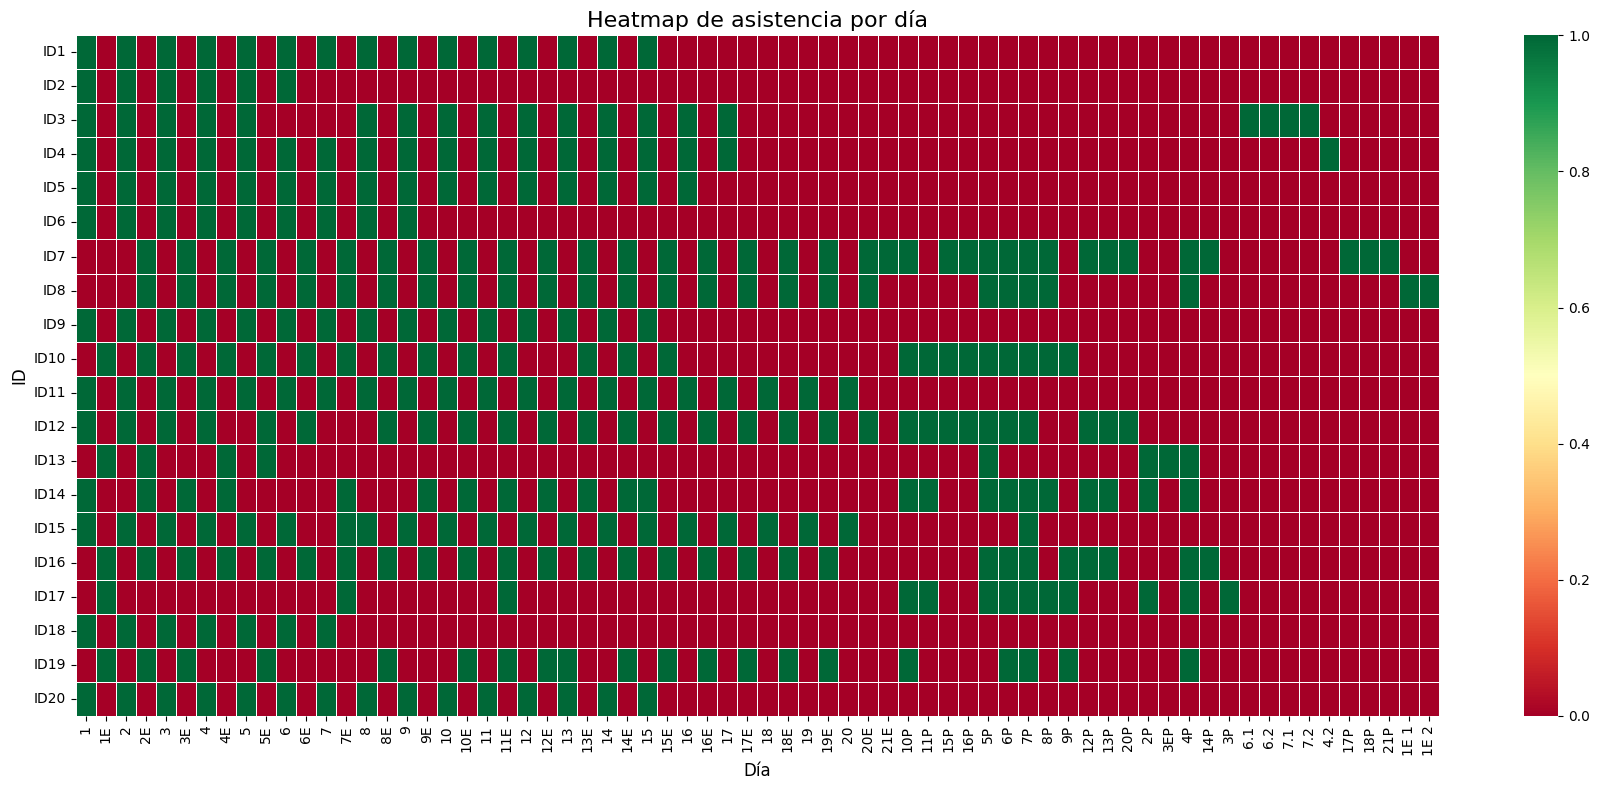


Racha máxima de días consecutivos:
      id  max_consecutivos
0    ID1                15
1   ID10                11
2   ID11                20
3   ID12                13
4   ID13                 2
5   ID14                 7
6   ID15                20
7   ID16                19
8   ID17                 1
9   ID18                 7
10  ID19                10
11   ID2                 6
12  ID20                15
13   ID3                10
14   ID4                17
15   ID5                16
16   ID6                 9
17   ID7                20
18   ID8                19
19   ID9                15

Días registrados por ID:
      id  dias_registrados  numero_id
0    ID1                15          1
11   ID2                 6          2
13   ID3                19          3
14   ID4                18          4
15   ID5                16          5
16   ID6                 9          6
17   ID7                35          7
18   ID8                26          8
19   ID9                15   

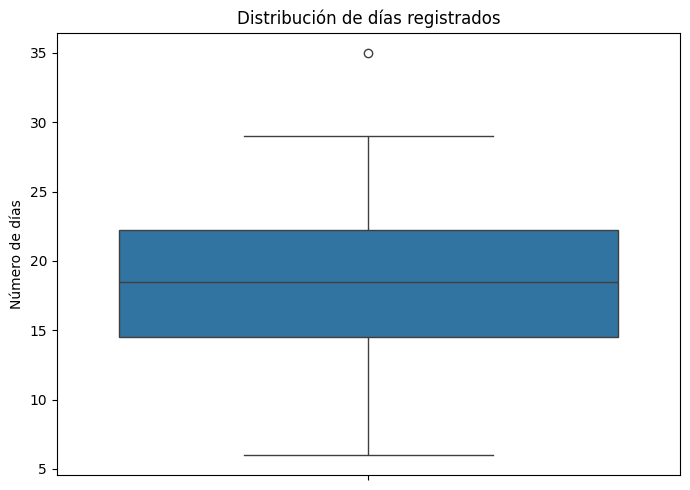

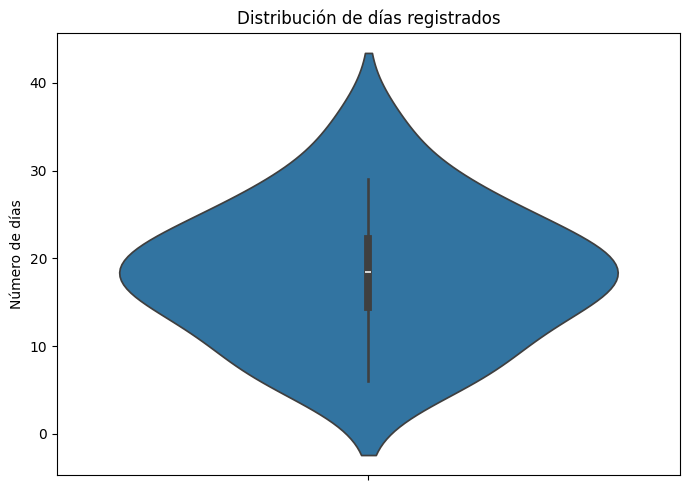

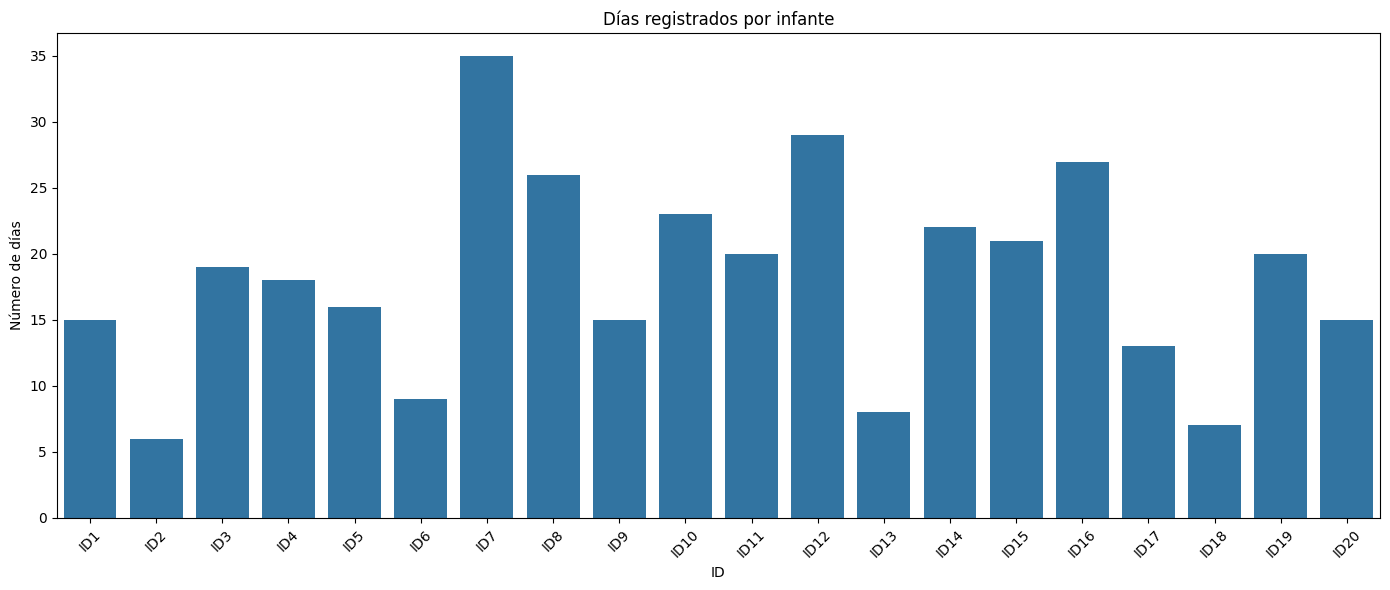

In [ ]:
# ==========================================
# LIMPIAR DATOS
# ==========================================

# Quitar espacios
df["dia"] = df["dia"].astype(str).str.strip()
df["id"] = df["id"].astype(str).str.strip()

# Eliminar valores inválidos
df = df[
    ~df["dia"].isin(["-", "", "nan", "None"])
]

# ==========================================
# CREAR COLUMNA DE ASISTENCIA
# ==========================================

df["asistencia"] = 1


orden_ids = sorted(
    df["id"].unique(),
    key=lambda x: int(x.replace("ID", ""))
)


def ordenar_dia(x):

    x = str(x).strip()

    # Días especiales tipo 2E
    if x.endswith("E"):

        numero = x[:-1]

        if numero.isdigit():
            return (int(numero), 1)

    # Días normales
    if x.isdigit():
        return (int(x), 0)

    # Cualquier otro caso
    return (999, 999)


orden_dias = sorted(
    df["dia"].unique(),
    key=ordenar_dia
)

# MATRIZ PARA HEATMAP

heatmap_data = df.pivot_table(
    index="id",
    columns="dia",
    values="asistencia",
    fill_value=0
)

# Reordenar filas y columnas
heatmap_data = heatmap_data.reindex(
    index=orden_ids,
    columns=orden_dias
)

# HEATMAP

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Heatmap de asistencia por día", fontsize=16)
plt.xlabel("Día", fontsize=12)
plt.ylabel("ID", fontsize=12)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

# SECUENCIA MÁS LARGA DE DÍAS CONSECUTIVOS

# Solo usar días numéricos normales
df_numerico = df.copy()

df_numerico["dia_num"] = (
    df_numerico["dia"]
    .str.replace("E", "", regex=False)
)

df_numerico = df_numerico[
    df_numerico["dia_num"].str.isdigit()
]

df_numerico["dia_num"] = df_numerico["dia_num"].astype(int)

resultados = []

for nombre_id, grupo in df_numerico.groupby("id"):

    dias = sorted(grupo["dia_num"].unique())

    if len(dias) == 0:
        continue

    max_racha = 1
    racha_actual = 1

    for i in range(1, len(dias)):

        if dias[i] == dias[i-1] + 1:

            racha_actual += 1

            max_racha = max(
                max_racha,
                racha_actual
            )

        else:
            racha_actual = 1

    resultados.append({
        "id": nombre_id,
        "max_consecutivos": max_racha
    })

rachas = pd.DataFrame(resultados)

print("\nRacha máxima de días consecutivos:")
print(rachas)

# CONTEO DE DÍAS REGISTRADOS

conteo = (
    df.groupby("id")["dia"]
    .nunique()
    .reset_index(name="dias_registrados")
)

# Ordenar IDs
conteo["numero_id"] = (
    conteo["id"]
    .str.replace("ID", "")
    .astype(int)
)

conteo = conteo.sort_values("numero_id")

print("\nDías registrados por ID:")
print(conteo)

# BOXPLOT

plt.figure(figsize=(7,5))

sns.boxplot(
    y=conteo["dias_registrados"]
)

plt.title("Distribución de días registrados")
plt.ylabel("Número de días")

plt.tight_layout()

plt.show()

# VIOLINPLOT

plt.figure(figsize=(7,5))

sns.violinplot(
    y=conteo["dias_registrados"]
)

plt.title("Distribución de días registrados")
plt.ylabel("Número de días")

plt.tight_layout()

plt.show()

# BARRAS POR ID

plt.figure(figsize=(14,6))

sns.barplot(
    data=conteo,
    x="id",
    y="dias_registrados"
)

plt.title("Días registrados por infante")
plt.xlabel("ID")
plt.ylabel("Número de días")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()